<b>Overview:</b>

This is an Exploratory Data Analysis made to the 2019 New York City Airbnb Open Data. The main goal of this is to answer the following business question: 

<b>Which NYC neighborhood had the highest average Airbnb listing price in 2019, and what factors contributed to its high pricing? Additionally, is there a statistical relationship between Airbnb prices and the number of reviews a listing receives?</b>


<b>Data:</b>

The data was provided by Inside Airbnb and can be found in the following link:  https://www.kaggle.com/code/whyalwaysme/ab-nyc-2019

<b>Libraries:</b>


In [21]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder


import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import warnings

We'll start by importing the data and explore some basic information about it.

In [4]:
data=pd.read_csv('AB_NYC_2019.csv')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

The data has 48895 rows and 16 columns. It helps better understand the data set by checking the first and last few rows and the information about the data. 



In [5]:
# Check the first few rows
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [6]:
# Check the last few rows
data.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,NaN,1,23


In [7]:
# Check basic statistics of the dataset
data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


Let's check for and visualize missing values in the data

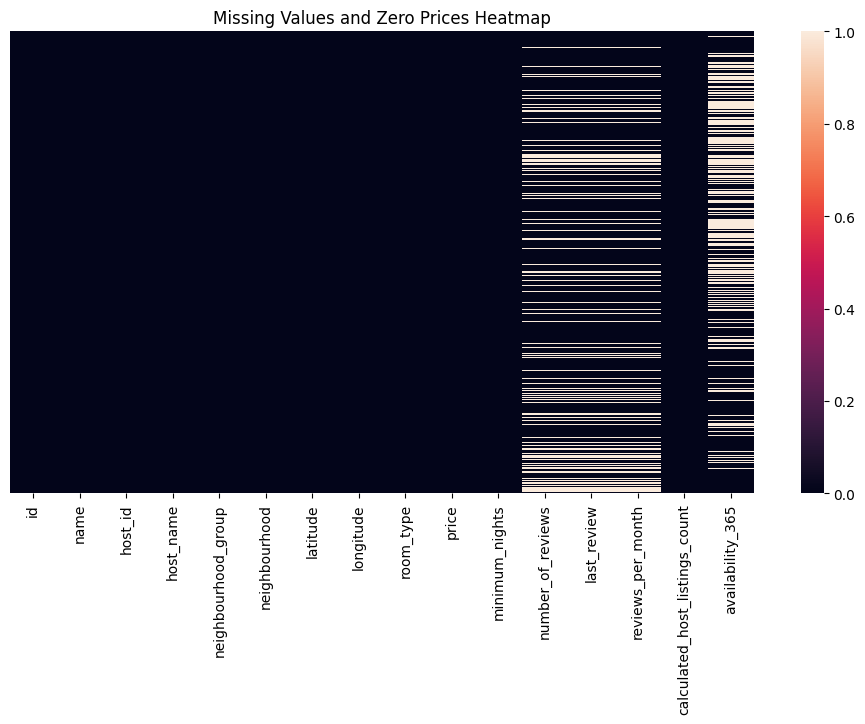


Summary of problematic values:
--------------------------------------------------

Null values count:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Zero values count in price: 11

Total problematic values in price: 11


In [20]:
# Create a mask where True represents either null values or zero prices
mask = data.isnull() | (data == 0)

# For the price column specifically, mark zeros as True
mask['price'] = (data['price'] == 0) | data['price'].isnull()

plt.figure(figsize=(12, 6))
sns.heatmap(mask, yticklabels=False, cbar=True)
plt.title('Missing Values and Zero Prices Heatmap')
plt.show()

# Print summary
print("\nSummary of problematic values:")
print("-" * 50)
print("\nNull values count:")
print(data.isnull().sum())
print("\nZero values count in price:", len(data[data['price'] == 0]))
print("\nTotal problematic values in price:", 
      len(data[data['price'].isnull() | (data['price'] == 0)]))

There's a high number of listings that have zero reviews. Without having the information of when the listing has been created, it is hard to create causal connection. However, these are likely to be newer listings in the market that haven't yet had much or any reservations. We will treat these columns as outliers and drop them from the data set. Additionally, there are 11 price values as $0, which can be dropped from the data set. We also want to make sure we drop values that are above the 99th percentile for price.

Other good candidates for preprocessing are the columns: id, name and host_name they are unlikely to have a connection to the price.

In [24]:

def preprocess_airbnb_data(data):
    # Create a copy of the data to avoid modifying the original
    df = data.copy()
    
    # 1. Handle price outliers and zero prices
    # Remove any zero prices as they're likely errors
    df = df[df['price'] > 0]
    
    # Cap prices at 99th percentile to handle extreme outliers
    price_99th = df['price'].quantile(0.99)
    df['price'] = df['price'].clip(upper=price_99th)

    # 2. Drop rows with null values in last_review and reviews_per_month
    df = df.dropna(subset=['last_review', 'reviews_per_month'])
    
    # 3. Drop unnecessary columns
    columns_to_drop = ['id', 'name', 'host_name']
    df = df.drop(columns=columns_to_drop)
    
    return df

# Apply preprocessing
processed_data = preprocess_airbnb_data(data)

In [25]:
processed_data.describe()

,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,3.883300e+04,38833.000000,38833.000000,38833.000000,38833.000000,38833.000000,38833.000000,38833.000000,38833.000000
mean,6.423943e+07,40.728139,-73.951156,137.313651,5.867561,29.295393,1.373128,5.164602,114.878222
std,7.589466e+07,0.054992,0.046697,111.208711,17.386070,48.188127,1.680391,26.299034,129.549091
min,2.438000e+03,40.506410,-74.244420,10.000000,1.000000,1.000000,0.010000,1.000000,0.000000
25%,7.033514e+06,40.688640,-73.982470,69.000000,1.000000,3.000000,0.190000,1.000000,0.000000
50%,2.837092e+07,40.721720,-73.954810,101.000000,2.000000,9.000000,0.720000,1.000000,55.000000
75%,1.018090e+08,40.763000,-73.935020,170.000000,4.000000,33.000000,2.020000,2.000000,229.000000
max,2.738417e+08,40.913060,-73.712990,799.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [26]:
processed_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38833 entries, 0 to 48852
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_id                         38833 non-null  int64  
 1   neighbourhood_group             38833 non-null  object 
 2   neighbourhood                   38833 non-null  object 
 3   latitude                        38833 non-null  float64
 4   longitude                       38833 non-null  float64
 5   room_type                       38833 non-null  object 
 6   price                           38833 non-null  int64  
 7   minimum_nights                  38833 non-null  int64  
 8   number_of_reviews               38833 non-null  int64  
 9   last_review                     38833 non-null  object 
 10  reviews_per_month               38833 non-null  float64
 11  calculated_host_listings_count  38833 non-null  int64  
 12  availability_365                38833

Post preprocessing, we are down to 38833 records in the data set. Let's start by exploring the number of listings per neighborhood

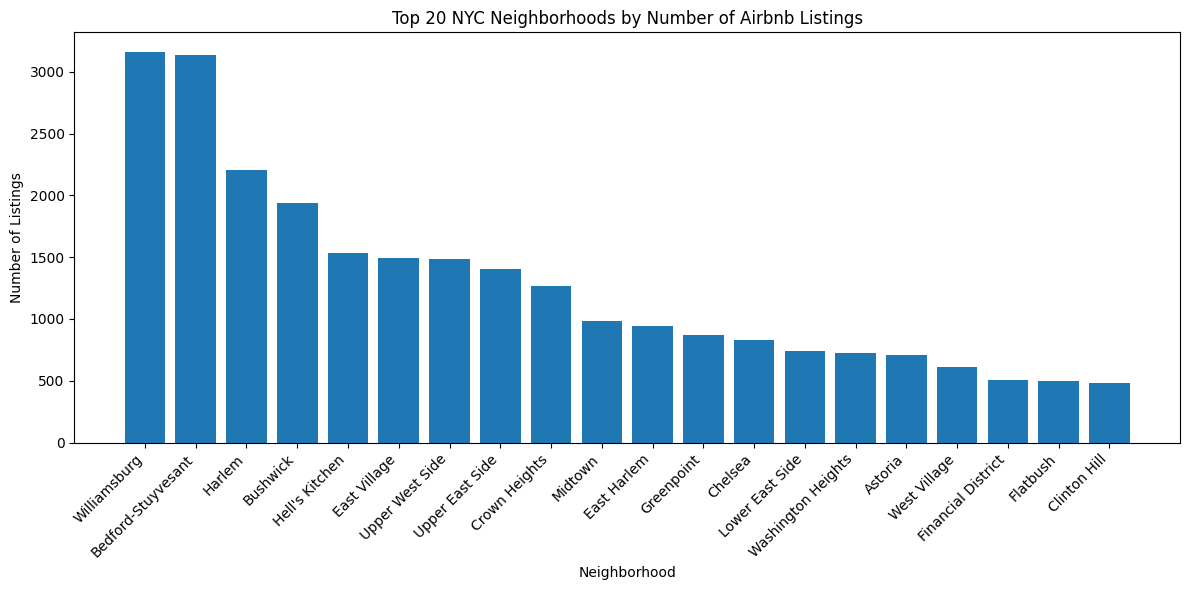

In [27]:
# Count listings per neighborhood
neighborhood_counts = processed_data['neighbourhood'].value_counts()

# Show only top 20 neighborhoods to avoid overcrowded histogram
top_20_neighborhoods = neighborhood_counts.head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_20_neighborhoods.index, top_20_neighborhoods.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 NYC Neighborhoods by Number of Airbnb Listings')
plt.xlabel('Neighborhood')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

# Show the plot
plt.show()

And by Neighborhood group:

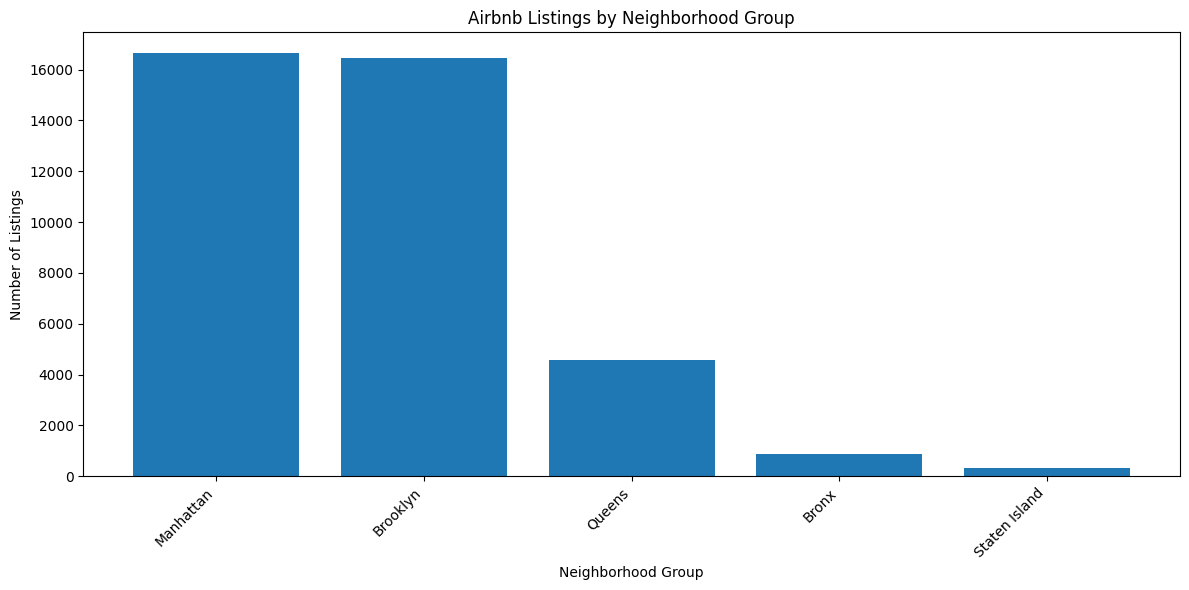

In [28]:
neighborhood_groupcounts = processed_data['neighbourhood_group'].value_counts()
plt.figure(figsize=(12, 6))
plt.bar(neighborhood_groupcounts.index, neighborhood_groupcounts.values)
plt.xticks(rotation=45, ha='right')
plt.title('Airbnb Listings by Neighborhood Group')
plt.xlabel('Neighborhood Group')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

# Show the plot
plt.show()


When it comes to the number of listings per neighborhood group, Manhattan has the most listings, followed by Brooklyn, Queens, and Staten Island. When it comes to the number of listings per neighborhood, Williamsburg and Bedford-Stuyvesant are the neighborhoods with the most listings, with just over 3000, while Flatbush and Clinton Hill tail the top 20, with just around 500 listings each. In order to get a better understanding of the data, we can also look at the average price per neighborhood group, as that answers the first part of our business question.

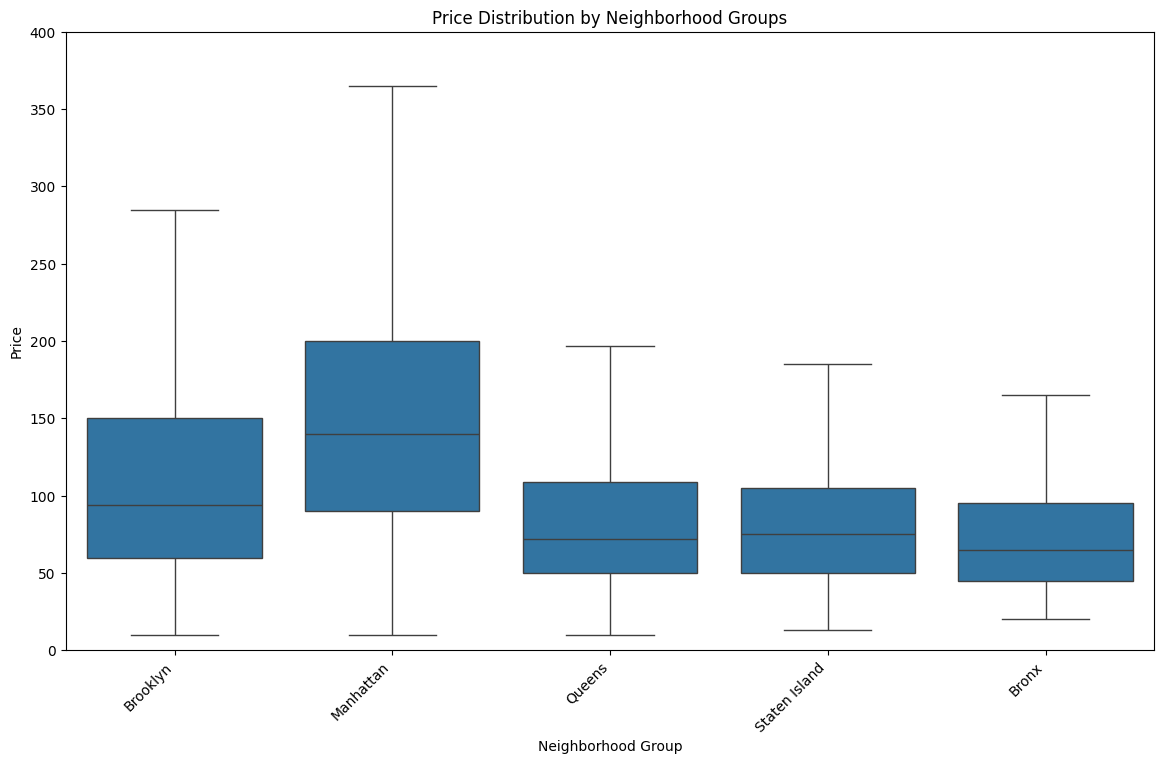


Summary statistics for neighborhood groups:
                     price                        room_type
                     count median    mean     std     count
neighbourhood_group                                        
Bronx                 1091   65.0   87.50  106.71      1091
Brooklyn             20104   90.0  124.38  186.87     20104
Manhattan            21661  150.0  196.88  291.38     21661
Queens                5666   75.0   99.52  167.10      5666
Staten Island          373   75.0  114.81  277.62       373


In [ ]:
# Create figure with larger size
plt.figure(figsize=(12, 8))

# Create boxplot without outliers
sns.boxplot(data=processed_data, 
            x='neighbourhood_group', 
            y='price',
            showfliers=False)

# Get 97th percentile of prices for y-axis limit
y_limit = processed_data['price'].quantile(0.97)
plt.ylim(0, y_limit)

# Rotate x-axis labels and adjust their position
plt.xticks(rotation=45, ha='right')
plt.title('Price Distribution by Neighborhood Groups')
plt.xlabel('Neighborhood Group')
plt.ylabel('Price')

# Adjust layout with specific margins
plt.tight_layout(pad=2.0)
plt.show()

# Print summary statistics for neighborhood groups
print("\nSummary statistics for neighborhood groups:")
print(data.groupby('neighbourhood_group')
      .agg({
          'price': ['count', 'median', 'mean', 'std'],
          'room_type': 'count'
      })
      .round(2))

Manhattan and Brooklyn stand out as the neighborhood groups with highest prices. Excluding extreme outliers, listings in Manhattan have a median price of $150 per night. Prices are lowest in Bronx, with a median price of just $65 per night.

We want to check what are the attributes that may allow hosts to set a higher price in Manhattan and Brooklyn specifically. For that, we'll create a correlation matrix, only with Manhattan and Brooklyn data. We filter out weak correlations (r<0.3) for a cleaner visualization.

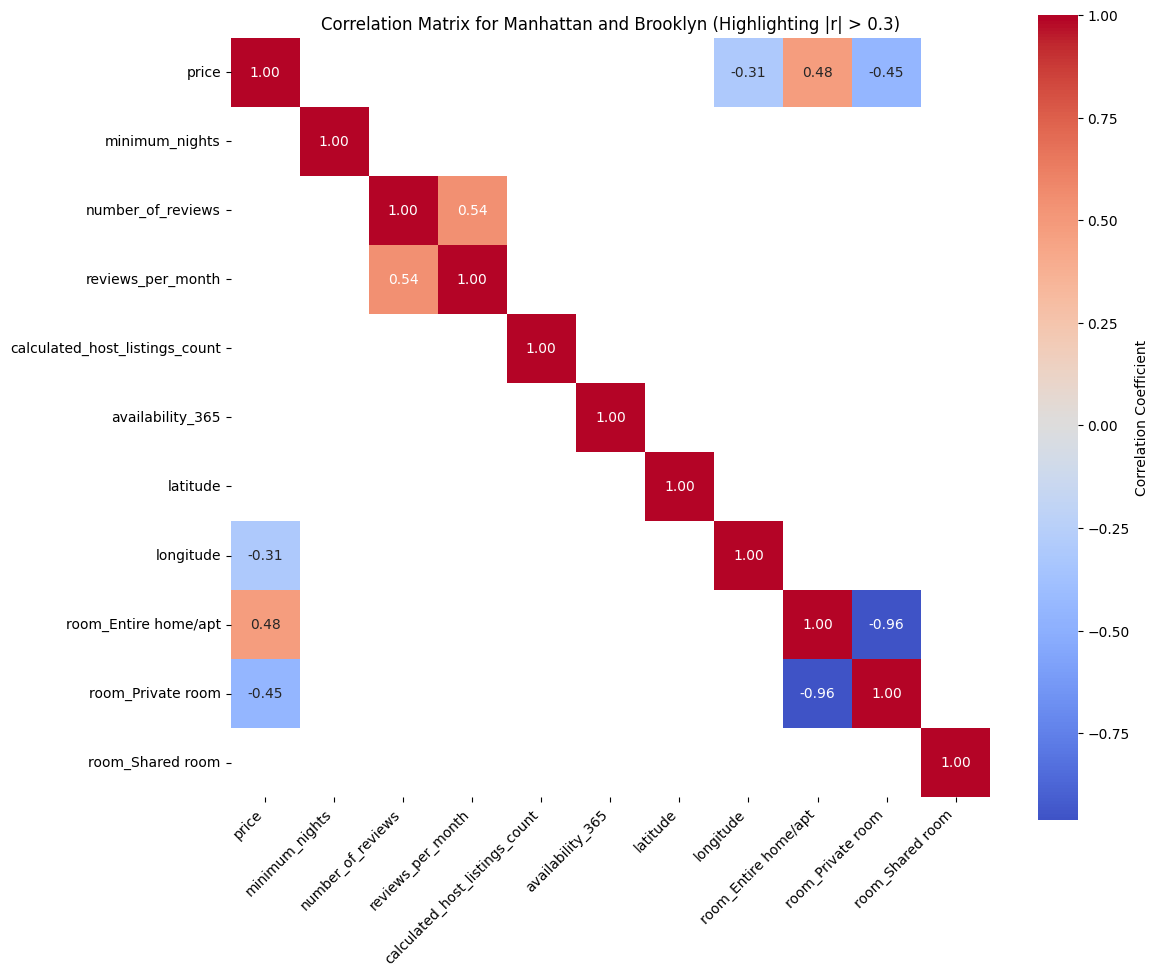


Strongest correlations (|r| > 0.3):
room_Private room     room_Entire home/apt   -0.961286
reviews_per_month     number_of_reviews       0.543811
room_Entire home/apt  price                   0.475979
room_Private room     price                  -0.450208
longitude             price                  -0.309007
dtype: float64


In [75]:
# Filter for Manhattan and Brooklyn
filtered_data = processed_data[processed_data['neighbourhood_group'].isin(['Manhattan', 'Brooklyn'])]

# Create one-hot encoded variables for room_type
room_type_dummies = pd.get_dummies(filtered_data['room_type'], prefix='room')

# Combine numerical columns with room type dummies
numerical_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
                 'calculated_host_listings_count', 'availability_365', 'latitude', 'longitude']

# Combine all features
combined_data = pd.concat([filtered_data[numerical_cols], room_type_dummies], axis=1)

# Create correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = combined_data.corr()

# Create mask for strong correlations (absolute value > 0.3)
strong_mask = np.abs(correlation_matrix) > 0.3

# Create heatmap
sns.heatmap(correlation_matrix, 
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            square=True,
            mask=~strong_mask,  # Mask weak correlations
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Correlation Matrix for Manhattan and Brooklyn (Highlighting |r| > 0.3)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print strongest correlations
print("\nStrongest correlations (|r| > 0.3):")
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
strong_correlations = upper[np.abs(upper) > 0.3]
print(strong_correlations.unstack().dropna().sort_values(key=abs, ascending=False))

By the correlation matrix above, the elements that most influence Price in Manhattan and Brooklyn seem to be the room type, with the Entire home/apt category having a moderately strong positive correlation with price (r=0.476) and the Private room category having a moderately strong negative correlation with price (r=-0.450). The longitude of the property also has a moderately strong negative correlation with price (r=-0.309) - this makes sense as the areas of Manhattan as the overall price of property decreases as the longitude increases - SoHo is one of the most expensive areas in Manhattan, while East Harlem is the cheapest. From the correlation matrix, it doesn't seem that the number of reviews is strongly correlated with the price.

/var/folders/qb/b688h2y51t51sp1bhv6vzdqr0000gn/T/ipykernel_20515/1877725051.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['review_categories'] = pd.cut(filtered_data['number_of_reviews'],
/var/folders/qb/b688h2y51t51sp1bhv6vzdqr0000gn/T/ipykernel_20515/1877725051.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['minimum_nights_categories'] = pd.cut(filtered_data['minimum_nights'],


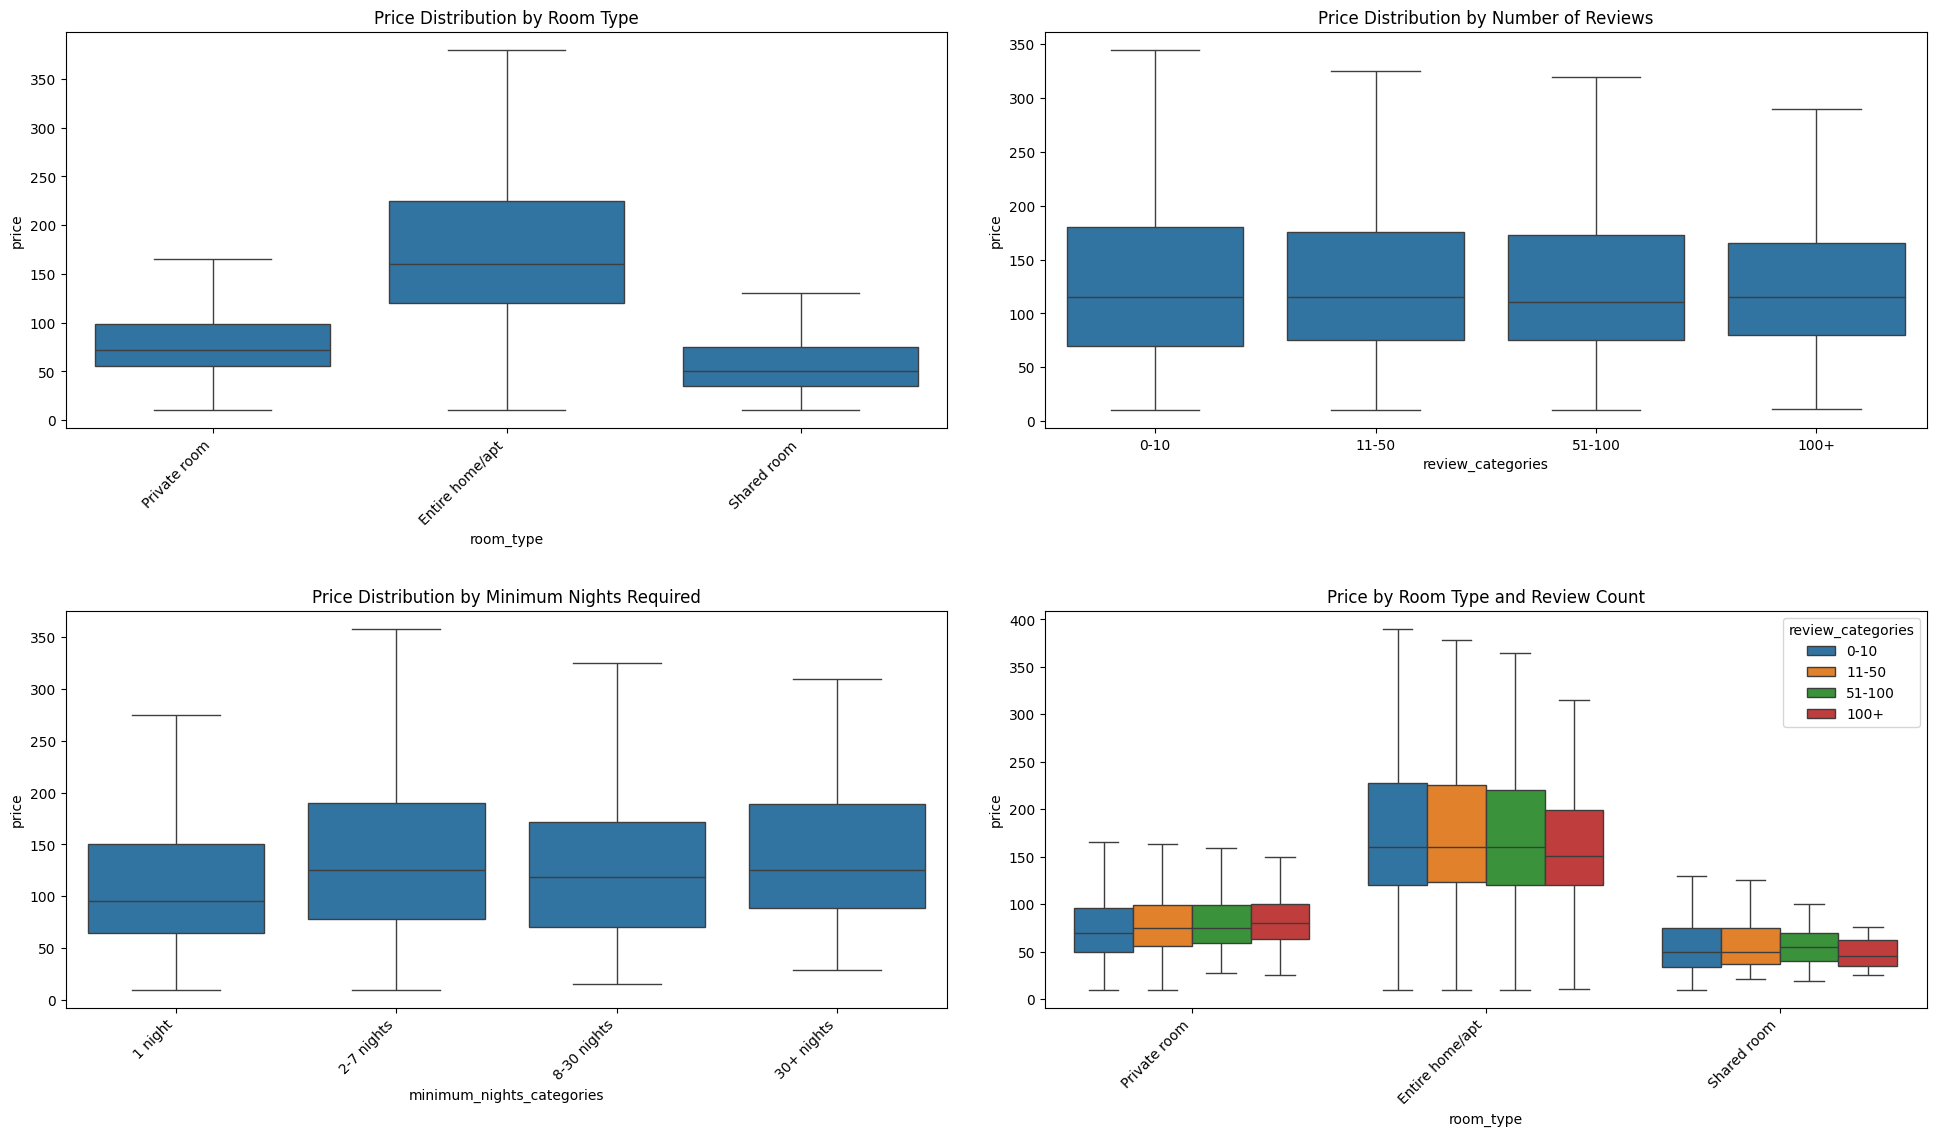


Median Prices by Room Type:
room_type
Entire home/apt    160.0
Private room        72.0
Shared room         50.0
Name: price, dtype: float64

Median Prices by Review Category:
review_categories
0-10      115.0
11-50     115.0
51-100    111.0
100+      115.0
Name: price, dtype: float64

Median Prices by Minimum Nights Category:
minimum_nights_categories
1 night         95.0
2-7 nights     125.0
8-30 nights    119.0
30+ nights     125.0
Name: price, dtype: float64


/var/folders/qb/b688h2y51t51sp1bhv6vzdqr0000gn/T/ipykernel_20515/1877725051.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(filtered_data.groupby('review_categories')['price'].median().round(2))
/var/folders/qb/b688h2y51t51sp1bhv6vzdqr0000gn/T/ipykernel_20515/1877725051.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(filtered_data.groupby('minimum_nights_categories')['price'].median().round(2))


In [76]:
# Create a figure with multiple subplots
fig = plt.figure(figsize=(20, 12))

# 1. Room Type vs Price
plt.subplot(2, 2, 1)
sns.boxplot(data=filtered_data, x='room_type', y='price', showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.title('Price Distribution by Room Type')

# 2. Number of Reviews vs Price
plt.subplot(2, 2, 2)
# Create categories for number of reviews
filtered_data['review_categories'] = pd.cut(filtered_data['number_of_reviews'], 
                                 bins=[0, 10, 50, 100, float('inf')],
                                 labels=['0-10', '11-50', '51-100', '100+'])
sns.boxplot(data=filtered_data, x='review_categories', y='price', showfliers=False)
plt.title('Price Distribution by Number of Reviews')

# 3. Minimum Nights vs Price
plt.subplot(2, 2, 3)
# Create categories for minimum nights
filtered_data['minimum_nights_categories'] = pd.cut(filtered_data['minimum_nights'], 
                                         bins=[0, 1, 7, 30, float('inf')],
                                         labels=['1 night', '2-7 nights', '8-30 nights', '30+ nights'])
sns.boxplot(data=filtered_data, x='minimum_nights_categories', y='price', showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.title('Price Distribution by Minimum Nights Required')

# 4. Room Type and Review Count Combined
plt.subplot(2, 2, 4)
sns.boxplot(data=filtered_data, x='room_type', y='price', hue='review_categories', showfliers=False)
plt.xticks(rotation=45, ha='right')
plt.title('Price by Room Type and Review Count')

# Adjust layout
plt.tight_layout(pad=3.0)
plt.show()

# Print summary statistics
print("\nMedian Prices by Room Type:")
print(filtered_data.groupby('room_type')['price'].median().round(2))

print("\nMedian Prices by Review Category:")
print(filtered_data.groupby('review_categories')['price'].median().round(2))

print("\nMedian Prices by Minimum Nights Category:")
print(filtered_data.groupby('minimum_nights_categories')['price'].median().round(2))

This visualization hints that, as visualized before, Entire home/apt has more than double median price when of Private and Shared rooms. The number of reviews doesn't seem to have a statistically significant effect on price. The Minimum number of nights seems to be correlated with a smaller price, but only for properties that allow a single night reservation.